# Aula 2 — Regressão linear item a item, modelo múltiplo e regularização

**Análise Preditiva** · material de aula (fora do livro) · continuação da [aula 1](aula1_descritiva_diagnostica.ipynb) sobre o dataset da limonada.

**Roteiro desta aula:**

1. **Retomada** — o que a aula 1 deixou pronto.
2. **Regressão item a item** — uma reta para cada variável contra `vendas`; avaliação de cada ajuste (a, b, r, R², RMSE) e os resíduos de cada um.
3. **Preparação** — `X`, `y`, treino/teste, padronização sem vazamento.
4. **Modelo múltiplo** — os quatro itens juntos: coeficientes, avaliação, resíduos.
5. **Feedback de retorno** — o que o modelo responde, e o que exige dado novo.
6. **Ridge e Lasso** — regularização para reduzir parâmetros.
7. **Transformação de variáveis** — o log que a aula 1 deixou anotado.


In [1]:
# --- roda igual na sua máquina e no Colab ------------------------------
# No Colab não há repositório: o CSV é baixado direto do GitHub.
import pathlib, urllib.request

RAW = "https://raw.githubusercontent.com/GHDaru/machinelearning/main/"
CSV = "ml-zero/dados/limonada/limonada.csv"

raiz = pathlib.Path.cwd()
for _ in range(5):
    if (raiz / "ml-zero").is_dir():
        break
    raiz = raiz.parent
else:
    raiz = pathlib.Path.cwd()

caminho = raiz / CSV
if not caminho.exists():
    caminho.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(RAW + CSV, caminho)
print("dados em:", caminho)

dados em: /home/user/machinelearning/ml-zero/dados/limonada/limonada.csv


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*vert.*")

# Paleta da aula: um matiz para o dado, laranja só quando há duas séries a
# contrastar, cinza para o que é contexto. Cor segue papel, não enfeite.
AZUL, LARANJA, CINZA = "#4477AA", "#EE7733", "#BBBBBB"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 10,
})

## 1. Retomada da aula 1

Três conclusões vêm na bagagem: `preco` é **binária** (0,30/0,50, só julho–agosto: termômetro disfarçado), `dia_semana` **não tem sinal** (fica fora), e a chuva é assimétrica com **curva** no par contra vendas (candidata a log). A tabela de correlações com o alvo:

In [3]:
df = pd.read_csv(caminho, parse_dates=["data"])
ITENS = ["temperatura", "precipitacao", "panfletos", "preco"]
df[ITENS + ["vendas"]].corr()["vendas"].drop("vendas").round(3).to_frame("r com vendas")

,r com vendas
temperatura,0.990
precipitacao,-0.909
panfletos,0.805
preco,0.513


## 2. Regressão item a item

Antes do modelo com tudo dentro, **uma reta para cada item**. Para um par $(x, y)$, os mínimos quadrados dão:

$$\hat{y} = a\,x + b \qquad a = \frac{S_{xy}}{S_{xx}} = \frac{\sum_i (x_i-\bar{x})(y_i-\bar{y})}{\sum_i (x_i-\bar{x})^2} \qquad b = \bar{y} - a\,\bar{x}$$

e na regressão **simples** o R² é exatamente o quadrado da correlação da aula 1: $R^2 = r^2$. A avaliação aqui é *in-sample* (o dado inteiro); a disciplina treino/teste entra no modelo múltiplo, seção 4.

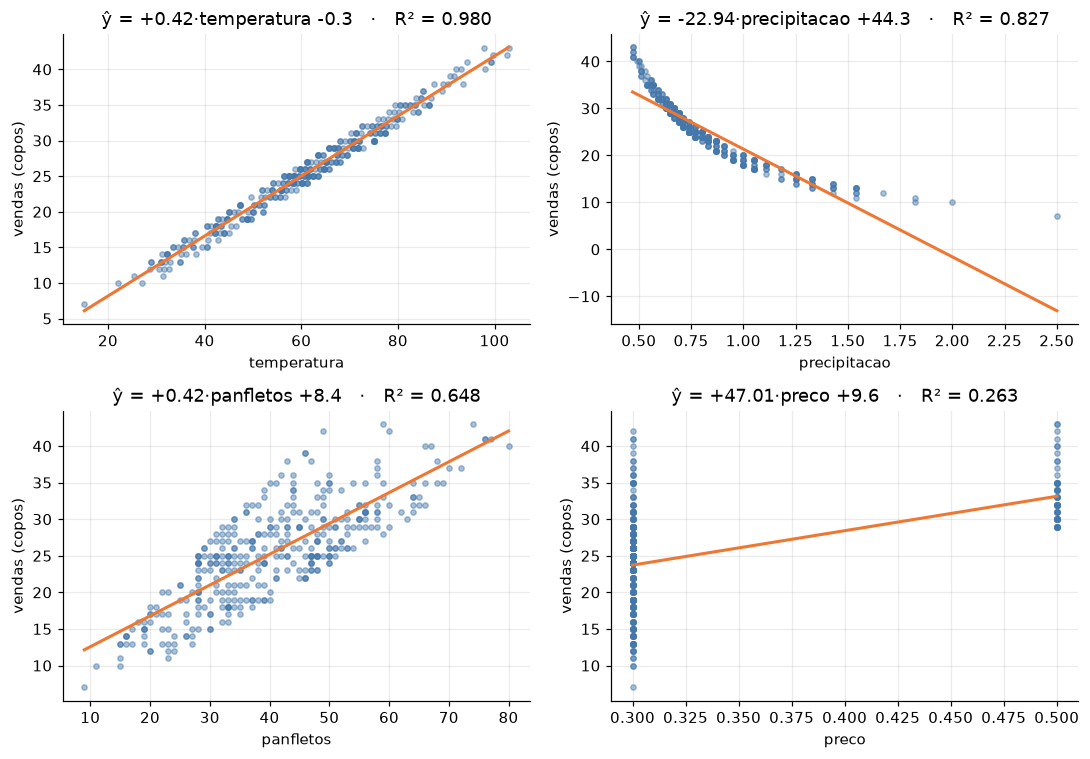

,a (inclinação),b (intercepto),r,R²,RMSE (copos)
item,,,,,
temperatura,0.4213,-0.2628,0.9898,0.9798,0.9792
precipitacao,-22.9444,44.2892,-0.9092,0.8267,2.8661
panfletos,0.4212,8.3560,0.8052,0.6483,4.0825
preco,47.0148,9.6216,0.5129,0.2631,5.9096


In [4]:
def ajusta_item(x: pd.Series, y: pd.Series):
    """Mínimos quadrados de um par: devolve (a, b, r, R², RMSE)."""
    a = ((x - x.mean()) * (y - y.mean())).sum() / ((x - x.mean()) ** 2).sum()
    b = y.mean() - a * x.mean()
    pred = a * x + b
    r = x.corr(y)
    r2 = 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    rmse = np.sqrt(((y - pred) ** 2).mean())
    return a, b, r, r2, rmse

y = df["vendas"]
fig, eixos = plt.subplots(2, 2, figsize=(10, 7))
linhas = []
for ax, col in zip(eixos.flat, ITENS):
    x = df[col]
    a, b, r, r2, rmse = ajusta_item(x, y)
    linhas.append({"item": col, "a (inclinação)": a, "b (intercepto)": b,
                   "r": r, "R²": r2, "RMSE (copos)": rmse})
    ax.scatter(x, y, s=12, color=AZUL, alpha=0.45)
    grade = np.linspace(x.min(), x.max(), 50)
    ax.plot(grade, a * grade + b, color=LARANJA, linewidth=2)
    ax.set(xlabel=col, ylabel="vendas (copos)",
           title=f"ŷ = {a:+.2f}·{col} {b:+.1f}   ·   R² = {r2:.3f}")

plt.tight_layout(); plt.show()
ajustes = pd.DataFrame(linhas).set_index("item")
ajustes.round(4)

**Leitura da tabela, item a item:**

- **temperatura** — sozinha, R² ≈ 0,98: a reta de um único item já explica quase tudo. A inclinação diz ~0,42 copo por °F.
- **precipitacao** — R² ≈ 0,83, e a inclinação assusta: ~−23 copos por polegada. A unidade importa: uma polegada de chuva é MUITA chuva (o dp é ~0,27).
- **panfletos** — R² ≈ 0,65… mas a aula 1 mostrou que panfleto anda com o calor. Quanto desse ajuste é panfleto de verdade?
- **preco** — R² ≈ 0,26 e a inclinação da ingenuidade: **+47 copos por real de aumento**. Está "bem ajustada" no sentido matemático e é a pior recomendação do dataset.

E um detalhe que arma a próxima seção: a soma dos quatro R² dá **~2,7** — mais de 270% da variância "explicada". Impossível? Não: os itens **compartilham o mesmo fator** (a estação), então cada um explica de novo o que o outro já explicava. É por isso que existe o modelo múltiplo.

### Os resíduos de cada ajuste

Ajuste bom não é só R² alto: é resíduo **sem padrão**. Os dois melhores itens, lado a lado:

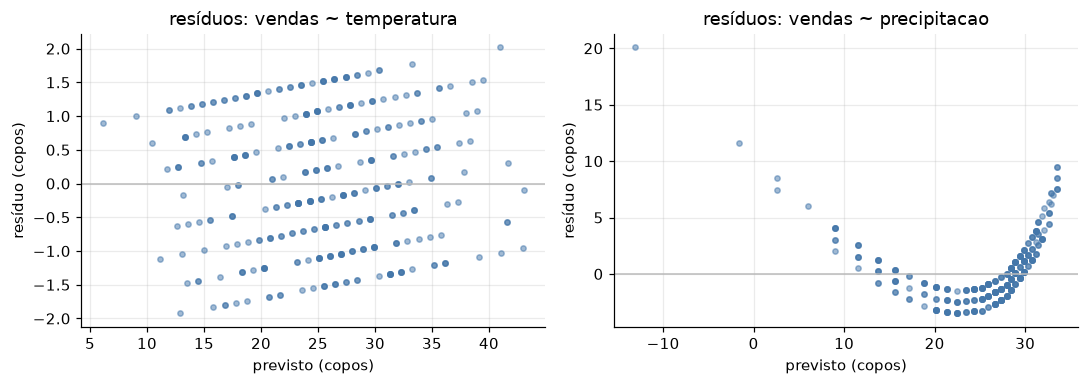

In [5]:
fig, eixos = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, col in zip(eixos, ["temperatura", "precipitacao"]):
    x = df[col]
    a, b, *_ = ajusta_item(x, y)
    pred = a * x + b
    ax.scatter(pred, y - pred, s=12, color=AZUL, alpha=0.5)
    ax.axhline(0, color=CINZA, linewidth=1)
    ax.set(xlabel="previsto (copos)", ylabel="resíduo (copos)",
           title=f"resíduos: vendas ~ {col}")
plt.tight_layout(); plt.show()

A diferença entre os dois painéis é a lição da seção:

- **temperatura**: resíduos pequenos (±2 copos) e centrados — a forma de reta serve. As "listras" diagonais não são defeito do modelo: `vendas` é **contagem inteira**, e cada listra é um valor inteiro de venda cortado pela reta contínua.
- **precipitacao**: os resíduos fazem um **U** — positivos na chuva fraca, negativos no meio, muito positivos na chuva forte. A reta erra *com padrão*: a relação verdadeira encurva (como o par da aula 1 já sugeria), e repare no painel anterior que essa reta chega a prever **vendas negativas** na chuva de 2,5 polegadas. Guarde: é exatamente o caso que a **transformação log** (seção 7) tenta consertar.

## 3. Preparação para o modelo múltiplo: `X`, `y`

Quatro decisões, cada uma com motivo:

1. **`X`** = os quatro itens · **`y`** = `vendas` (`dia_semana` ficou fora: a aula 1 mediu e não achou sinal).
2. **Divisão treino/teste (75/25)** com semente fixa — o teste é o "futuro simulado", intocado até a avaliação (prever o *futuro* de verdade, como a aula 1 anotou, pediria corte por data).
3. **Padronização** (média 0, desvio 1) — necessária para comparar coeficientes e essencial para Ridge/Lasso, cujas penalidades dependem da escala.
4. O `StandardScaler` **aprende só no treino** e é *aplicado* ao teste. Ajustá-lo no dado inteiro vazaria informação do teste para dentro do treino.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[ITENS]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler().fit(X_tr)            # aprende SÓ no treino
X_tr_z = scaler.transform(X_tr)
X_te_z = scaler.transform(X_te)                # o teste é transformado, nunca consultado

print(f"treino: {X_tr.shape} · teste: {X_te.shape}")
pd.DataFrame({"média (treino)": scaler.mean_, "dp (treino)": scaler.scale_},
             index=X.columns).round(3)

treino: (273, 4) · teste: (92, 4)


,média (treino),dp (treino)
temperatura,62.054,15.839
precipitacao,0.803,0.256
panfletos,41.161,13.392
preco,0.335,0.076


## 4. O modelo múltiplo

Com tudo padronizado, cada coeficiente responde: *quantos copos muda a previsão quando este atributo sobe **um desvio-padrão**, mantidos os demais constantes (na equação)*.

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

modelo = LinearRegression().fit(X_tr_z, y_tr)

coefs = pd.DataFrame({
    "coef (por dp)": modelo.coef_,
    "coef (unidade original)": modelo.coef_ / scaler.scale_,
    "a na regressão simples": ajustes["a (inclinação)"],
}, index=X.columns)
print(f"intercepto: {modelo.intercept_:.3f} copos (previsão no dia 'médio')")
coefs.round(4)

intercepto: 25.883 copos (previsão no dia 'médio')


,coef (por dp),coef (unidade original),a na regressão simples
temperatura,5.8364,0.3685,0.4213
precipitacao,-0.6509,-2.5402,-22.9444
panfletos,0.3021,0.0226,0.4212
preco,0.1134,1.4891,47.0148


**A terceira coluna é o confronto da aula.** Sozinho, cada item tinha uma inclinação; junto dos outros, quase todas encolhem — e a do `preco` derrete de **+47 copos por real** para pouco mais de **+1**: com a temperatura no modelo, quase todo o "efeito" do preço era o verão. O que sobra ainda não é efeito causal (o confundimento com a estação é perfeito); é o que o ajuste não conseguiu atribuir a outro item.

Repare também na colinearidade avisada pela aula 1: com temperatura×panfletos a +0,80, esses números individuais são instáveis por natureza.

### Avaliação nos dois conjuntos, contra a régua do melhor item

In [8]:
def avalia(nome, m, Xz_tr, Xz_te):
    linhas = []
    for rot, Xz, yy in [("treino", Xz_tr, y_tr), ("teste", Xz_te, y_te)]:
        p = m.predict(Xz)
        linhas.append({"conjunto": rot, "R²": r2_score(yy, p),
                       "MAE (copos)": mean_absolute_error(yy, p),
                       "RMSE (copos)": root_mean_squared_error(yy, p)})
    print(nome)
    return pd.DataFrame(linhas).set_index("conjunto").round(4)

# a régua: o melhor item sozinho (temperatura), com a MESMA disciplina treino/teste
so_temp = LinearRegression().fit(X_tr_z[:, [0]], y_tr)
p_temp = so_temp.predict(X_te_z[:, [0]])
print(f"régua — só temperatura: R² teste = {r2_score(y_te, p_temp):.4f}, "
      f"RMSE = {root_mean_squared_error(y_te, p_temp):.3f}\n")

avalia("Modelo múltiplo — 4 itens", modelo, X_tr_z, X_te_z)

régua — só temperatura: R² teste = 0.9819, RMSE = 0.927

Modelo múltiplo — 4 itens


,R²,MAE (copos),RMSE (copos)
conjunto,,,
treino,0.9811,0.7963,0.9327
teste,0.9824,0.7805,0.9138


O múltiplo melhora sobre a temperatura sozinha, mas **pouco** — a maior parte do sinal era linear e já morava num item. Essa comparação é a versão local do "treine sempre um linear primeiro": o modelo seguinte só se justifica pelo que ganha **da régua**, não pelo número absoluto.

R² alto **nos dois conjuntos** (treino ≈ teste) afasta o sobreajuste; o erro típico é de menos de 1 copo. Antes de comemorar, os resíduos:

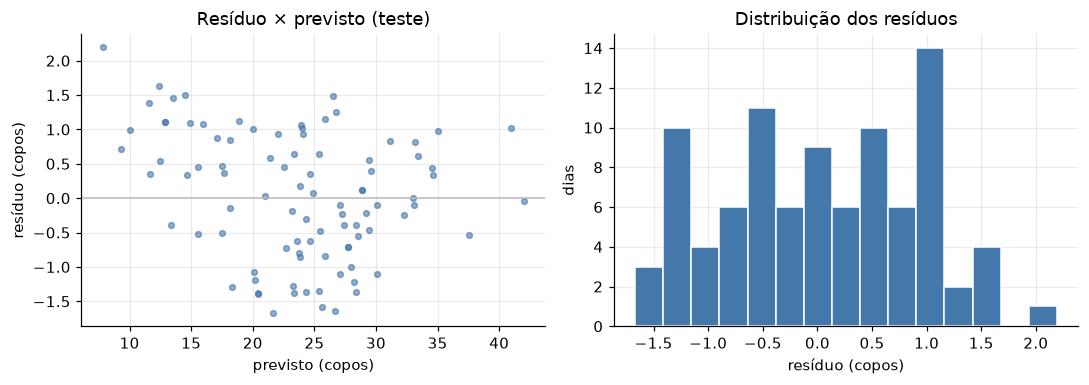

média dos resíduos: +0.038 · dp: 0.918


In [9]:
res_te = y_te - modelo.predict(X_te_z)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6))
a1.scatter(modelo.predict(X_te_z), res_te, s=14, color=AZUL, alpha=0.6)
a1.axhline(0, color=CINZA, linewidth=1)
a1.set(xlabel="previsto (copos)", ylabel="resíduo (copos)",
       title="Resíduo × previsto (teste)")
a2.hist(res_te, bins=15, color=AZUL, edgecolor="white")
a2.set(xlabel="resíduo (copos)", ylabel="dias", title="Distribuição dos resíduos")
plt.tight_layout(); plt.show()

print(f"média dos resíduos: {res_te.mean():+.3f} · dp: {res_te.std():.3f}")

**Leitura dos resíduos:** centrados em zero, sem funil (variância razoavelmente constante) e sem a curva que o item da chuva mostrava sozinho — os outros itens absorvem parte dela. Se aparecesse um **funil** (resíduos abrindo conforme o previsto cresce), o remédio seria transformação do alvo ou pesos; se aparecesse **curva**, faltaria termo não linear.

## 5. Feedback de retorno: o que devolver ao problema

O modelo vai bem **na pergunta certa** e falha em silêncio **na errada**:

| Pergunta | O modelo responde? |
|---|---|
| *Quantos copos vendo amanhã, dada a previsão do tempo?* | ✅ Sim — erro típico < 1 copo; serve para estoque e escala de pessoal |
| *Se eu subir o preço, vendo mais?* | ❌ **Não** — o coeficiente de `preco` é positivo por **confundimento** com a estação, e nenhum recorte destes dados separa os dois |
| *Panfletar se paga?* | ⚠️ Duvidoso — o coeficiente equivale a ~50 panfletos por copo extra, e parte disso é o calor do dia (colinearidade) |

**O que reportar de volta:** (a) previsão de demanda está resolvida; (b) para decidir **preço**, é preciso gerar dado novo — variar o preço *dentro do mesmo mês*, em dias comparáveis (um experimento, não mais coleta passiva); (c) coeficiente de variável de controle não se lê como efeito — é a "falácia da Tabela 2" (Westreich & Greenland, 2013).

## 6. Ridge e Lasso: reduzindo parâmetros

Com 4 itens não há o que reduzir. Para dar trabalho de verdade à regularização, **expandimos** o espaço: quadrados e interações (grau 2) → **14 atributos**. Aí comparamos:

- **Ridge (L2)** — encolhe todos os coeficientes, nenhum vira zero;
- **Lasso (L1)** — encolhe **e zera**: seleção de atributos embutida.

O hiperparâmetro α (força da penalidade) é escolhido por **validação cruzada no treino** — o teste continua intocado.

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV, LassoCV

pf = PolynomialFeatures(degree=2, include_bias=False).fit(X_tr)
nomes = pf.get_feature_names_out(X.columns)
X_tr2 = pf.transform(X_tr); X_te2 = pf.transform(X_te)

sc2 = StandardScaler().fit(X_tr2)
X_tr2_z = sc2.transform(X_tr2); X_te2_z = sc2.transform(X_te2)

alphas = np.logspace(-3, 2, 60)
lin14 = LinearRegression().fit(X_tr2_z, y_tr)
ridge = RidgeCV(alphas=alphas, cv=5).fit(X_tr2_z, y_tr)
lasso = LassoCV(alphas=alphas, cv=5, max_iter=50_000, random_state=42).fit(X_tr2_z, y_tr)

comp = []
for nome, m in [("Múltiplo (4 itens)", modelo), ("Linear (14 atrib.)", lin14),
                ("Ridge (14)", ridge), ("Lasso (14)", lasso)]:
    Xz = X_te_z if m is modelo else X_te2_z
    n_par = int((np.abs(m.coef_) > 1e-6).sum())
    comp.append({"modelo": nome, "R² teste": r2_score(y_te, m.predict(Xz)),
                 "RMSE teste": root_mean_squared_error(y_te, m.predict(Xz)),
                 "parâmetros ≠ 0": n_par,
                 "α": getattr(m, "alpha_", np.nan)})
pd.DataFrame(comp).set_index("modelo").round(4)

,R² teste,RMSE teste,parâmetros ≠ 0,α
modelo,,,,
Múltiplo (4 itens),0.9824,0.9138,4,NaN
Linear (14 atrib.),0.9905,0.6711,14,NaN
Ridge (14),0.9900,0.6888,14,0.6261
Lasso (14),0.9906,0.6663,8,0.0070


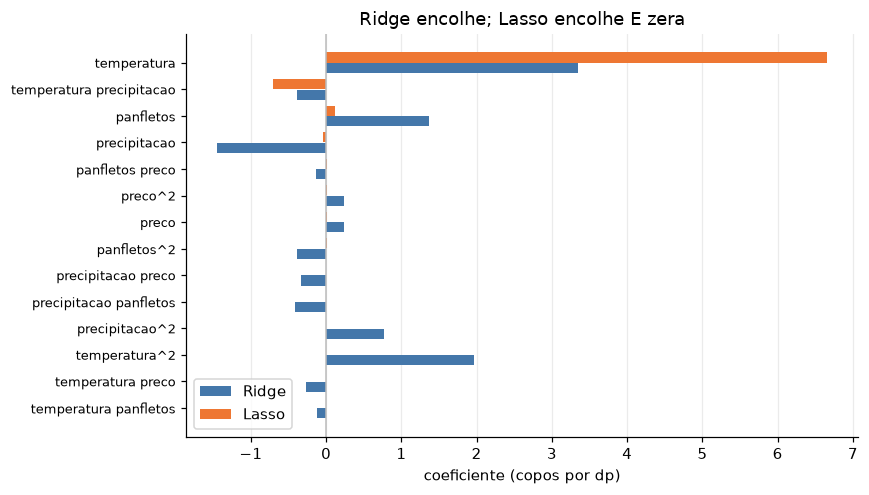

Lasso manteve 8 de 14:
  temperatura                    +6.662
  temperatura precipitacao       -0.712
  panfletos                      +0.121
  precipitacao                   -0.042
  panfletos preco                +0.015
  preco^2                        +0.014
  preco                          +0.013
  panfletos^2                    +0.013


In [11]:
ordem = np.argsort(np.abs(lasso.coef_))[::-1]
pos = np.arange(len(nomes))

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.barh(pos - 0.2, ridge.coef_[ordem][::-1], height=0.38, color=AZUL, label="Ridge")
ax.barh(pos + 0.2, lasso.coef_[ordem][::-1], height=0.38, color=LARANJA, label="Lasso")
ax.set_yticks(pos, [nomes[i] for i in ordem][::-1], fontsize=8.5)
ax.axvline(0, color=CINZA, linewidth=1)
ax.set_xlabel("coeficiente (copos por dp)")
ax.set_title("Ridge encolhe; Lasso encolhe E zera")
ax.legend()
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

mantidos = [(n, round(c, 3)) for n, c in zip(nomes, lasso.coef_) if abs(c) > 1e-6]
print(f"Lasso manteve {len(mantidos)} de {len(nomes)}:")
for n, c in sorted(mantidos, key=lambda t: -abs(t[1])):
    print(f"  {n:30s} {c:+.3f}")

**Leitura de engenharia:** os três modelos de 14 atributos empatam em R² de teste — mas o Lasso chega lá com **8 parâmetros** em vez de 14. Empate de desempenho + menos parâmetros = fique com o mais simples (é o modelo mais barato de manter e de explicar).

E há um achado *interpretável* na seleção: a interação **`temperatura × precipitacao` entra com sinal negativo** — chuva derruba mais venda justamente no dia quente, que era quando havia mais venda a perder. O modelo aditivo simples não tinha como dizer isso.

## 7. Transformação de variáveis: o log que ficou anotado

A aula 1 marcou `precipitacao` (assimetria ~1,9, cauda pesada) e a seção 2 viu o **U nos resíduos** do item. Transformar é hipótese — a medida decide.

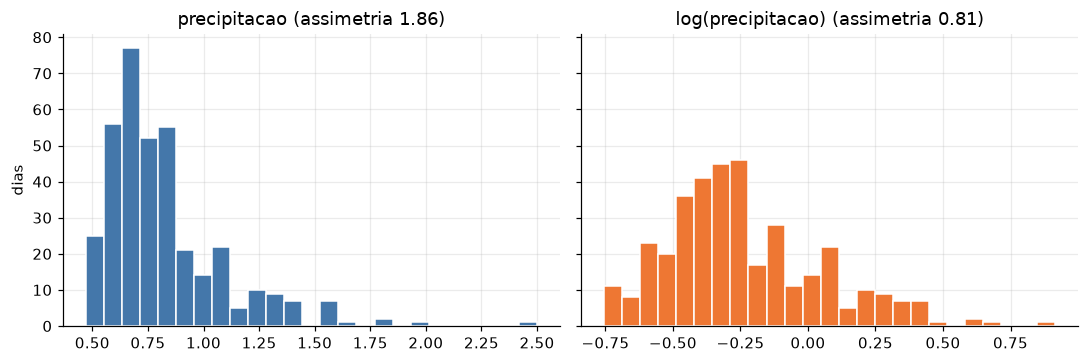

Múltiplo com log(precipitacao)


,R²,MAE (copos),RMSE (copos)
conjunto,,,
treino,0.9850,0.6902,0.8318
teste,0.9839,0.7233,0.8753


In [12]:
X_log = X.copy()
X_log["precipitacao"] = np.log(X_log["precipitacao"])   # min = 0,47 > 0: log direto

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
a1.hist(df.precipitacao, bins=25, color=AZUL, edgecolor="white")
a1.set(title=f"precipitacao (assimetria {df.precipitacao.skew():.2f})", ylabel="dias")
a2.hist(X_log.precipitacao, bins=25, color=LARANJA, edgecolor="white")
a2.set(title=f"log(precipitacao) (assimetria {X_log.precipitacao.skew():.2f})")
plt.tight_layout(); plt.show()

Xl_tr, Xl_te = X_log.loc[X_tr.index], X_log.loc[X_te.index]
scl = StandardScaler().fit(Xl_tr)
m_log = LinearRegression().fit(scl.transform(Xl_tr), y_tr)
avalia("Múltiplo com log(precipitacao)", m_log, scl.transform(Xl_tr), scl.transform(Xl_te))

A assimetria cai de ~1,9 para ~0,8 e o R² de teste **melhora pouco** (~0,982 → ~0,984). Lição dupla:

- a transformação se justifica pelo **resíduo e pela métrica**, não pelo hábito — no múltiplo, os outros itens já absorviam parte da curva da chuva, então o ganho é marginal;
- quando o ganho vier (e em dados reais de chuva costuma vir), o preço é a **leitura**: o coeficiente passa a ser "copos por dp de *log*-chuva".

## 8. Síntese da aula 2

1. **Item a item primeiro**: uma reta por variável dá a régua de cada uma — temperatura sozinha explica ~98%; o preço "bem ajustado" dava a pior recomendação (+47 copos/real).
2. **Os R² dos itens não somam** (~2,7): os itens compartilham a estação — é a razão de existir o modelo múltiplo.
3. **Resíduo com padrão é diagnóstico**: o U da chuva pediu transformação; a nuvem limpa da temperatura validou a reta.
4. **No múltiplo, os coeficientes se disciplinam**: o preço derrete de +47 para ~+1 — e nem esse resto é causa.
5. **A régua é o melhor item**, não o zero: o múltiplo ganhou pouco da temperatura sozinha, e é esse ganho que justifica (ou não) a complexidade.
6. **Ridge encolhe, Lasso seleciona**: empate de R² com 8 de 14 parâmetros → fique com o mais simples.
7. **Transformação se decide por medida**: o log domou a assimetria; a métrica disse "ganho pequeno".